<a href="https://colab.research.google.com/github/A-KOStov/Evlash-Valeria-2253/blob/main/Task04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задача про лодку

**Импорты**

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

**Уравнение**

In [51]:
x = sp.symbols('x', positive=True)
y = sp.Function('y')(x)
k = sp.symbols('k', positive=True)
ode = sp.Eq(y.diff(x), -y / (k*sp.sqrt(x**2 + y**2) - x))
ode

d                 -y(x)         
──(y(x)) = ─────────────────────
dx              ____________    
               ╱  2    2        
           k⋅╲╱  x  + y (x)  - x

**dsolve**

In [52]:
sol = sp.dsolve(ode)
sol

                      ⎛ x  ⎞
                 asinh⎜────⎟
                      ⎝y(x)⎠
log(y(x)) = C₁ - ───────────
                      k     

**Численное решение**

In [53]:
def solve_trajectory(x0, y0, k, n=2000):
    x = np.linspace(x0, 0, n)
    y = np.zeros(n); y[0] = y0
    dx = x[1] - x[0]
    for i in range(n-1):
        y[i+1] = y[i] - y[i]/(k*np.sqrt(x[i]**2 + y[i]**2) - x[i]) * dx
    return x, y

**График траектории и параметры**

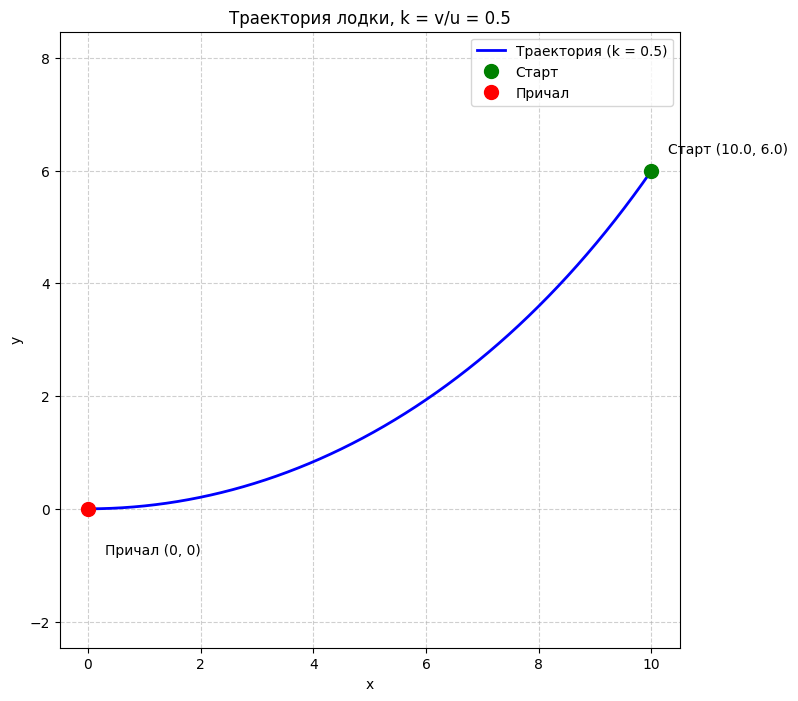

In [54]:
x0, y0 = 10.0, 6.0
u, v = 2.0, 1.0
k_ratio = v / u
tx, ty = solve_trajectory(x0, y0, k_ratio)
plt.figure(figsize=(8, 8))
plt.plot(tx, ty, 'b-', lw=2, label=f'Траектория (k = {k_ratio})')
plt.plot(x0, y0, 'go', ms=10, label='Старт')
plt.text(x0 + 0.3, y0 + 0.3, f'Старт ({x0}, {y0})')
plt.plot(0, 0, 'ro', ms=10, label='Причал')
plt.text(0.3, -0.8, 'Причал (0, 0)')
plt.title(f'Траектория лодки, k = v/u = {k_ratio}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, ls='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()

**Сравнение траекторий при разных k**

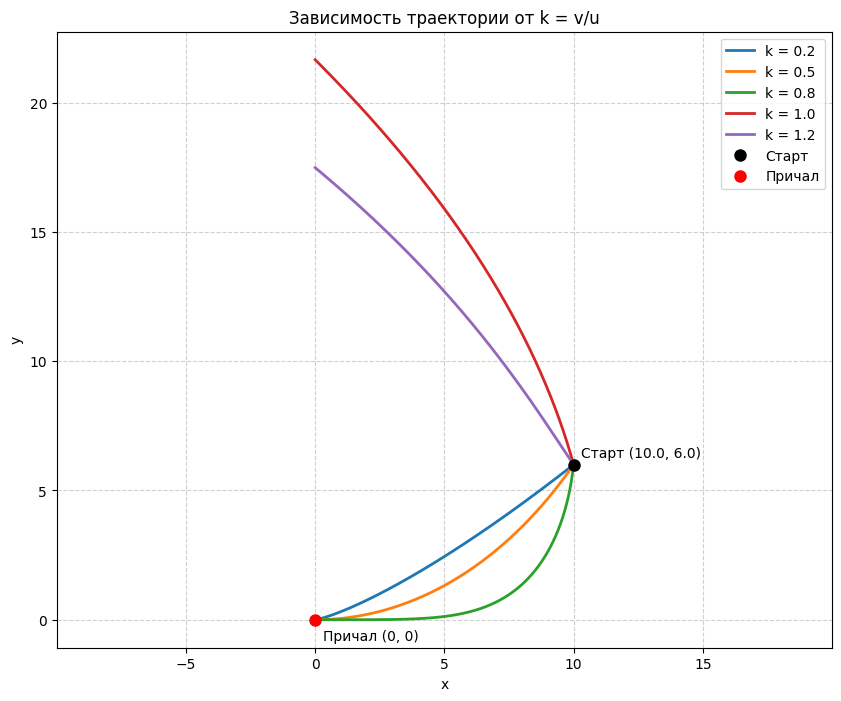

In [55]:
plt.figure(figsize=(10, 8))

for k_val in [0.2, 0.5, 0.8, 1.0, 1.2]:
    tx, ty = solve_trajectory(x0, y0, k_val)
    plt.plot(tx, ty, lw=2, label=f'k = {k_val}')
plt.plot(x0, y0, 'ko', ms=8, label='Старт')
plt.text(x0 + 0.3, y0 + 0.3, f'Старт ({x0}, {y0})')
plt.plot(0, 0, 'ro', ms=8, label='Причал')
plt.text(0.3, -0.8, 'Причал (0, 0)')
plt.title('Зависимость траектории от k = v/u')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, ls='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()